# Оглавление
* [Оглавление](#Оглавление)
* [Загрузка данных](#start)
    - [Анализ датасета](#analisys)
* [Исследовательский анализ данных](#Часть_1)
    * [Выводы](#1)      
* [Построение модели прогнозирования оттока клиентов.](#2)
    * [Выводы](#3)
    * [Подводим первые итоги](#3.5)
* [Кластеризация клиентов.](#4)    
    * [Выводы по итогам кластеризации клиентов и выделение основных портретов](#5) 
* [Общие выводы и рекомендации по целям проекта](#6)    

# Разработка стратегии взаимодействия с клиентами для фитнес-центра.

**Цели проекта**

- Спрогнозировать вероятность оттока (на уровне следующего месяца) для каждого клиента;
- Формирование типичных портретов клиентов: выделить несколько наиболее ярких групп и охарактеризовать их основные свойства;
проанализировать основные признаки, наиболее сильно влияющие на отток;
сформулировать основные выводы и разработать рекомендации по повышению качества работы с клиентами:
1) выделить целевые группы клиентов;
2) предложить меры по снижению оттока;
3) определить другие особенности взаимодействия с клиентами.


**Ход исследования:**

    Мне предстоит изучить сведения CSV-файла, проверить их на наличие ошибок, аномальных значений, а также соответствие столбцов стилю кода и типу данных. С библиотекой Seaborn, я сделаю свой анализ более наглядным. Каждый график и значимые части исследования я буду сопровождать комментариями и промежуточными выводами, сохраняя логику повествования. При помощи библиотеки scikit-learn я подберу оптимальную модель прогнозирования оттока клиентов, а методом кластеризации выделю основные портреты клиентов. 
    Завершая работу, я подведу итоги исследования и постараюсь дать несколько рекомендаций для заказчика.

In [1]:
# Необходимые библиотеки.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from scipy.cluster.hierarchy import dendrogram, linkage 


<a id='start' a>

# 1. Загрузка данных


In [2]:
# Загрузим датасет 
data = pd.read_csv('/datasets/gym_churn.csv')

#### В нашем распоряжении имеются данные, содержащие следующую информацию: 


**Данные клиента за предыдущий до проверки факта оттока месяц:**
- 'gender' — пол;

- 'Near_Location' — проживание или работа в районе, где находится фитнес-центр;

- 'Partner' — сотрудник компании-партнёра клуба (сотрудничество с компаниями, чьи сотрудники могут получать скидки на абонемент 
    в таком случае фитнес-центр хранит информацию о работодателе клиента);
    Promo_friends — факт первоначальной записи в рамках акции «приведи друга» (использовал промо-код от знакомого при оплате первого абонемента);

- 'Phone' — наличие контактного телефона;

- 'Age' — возраст;

- 'Lifetime' — время с момента первого обращения в фитнес-центр (в месяцах).


**Информация на основе журнала посещений, покупок и информация о текущем статусе абонемента клиента:**
- 'Contract_period' — длительность текущего действующего абонемента (месяц, 6 месяцев, год);
- 'Month_to_end_contract' — срок до окончания текущего действующего абонемента (в месяцах);
- 'Group_visits' — факт посещения групповых занятий;
- 'Avg_class_frequency_total' — средняя частота посещений в неделю за все время с начала действия абонемента;
- 'Avg_class_frequency_current_month' — средняя частота посещений в неделю за предыдущий месяц;
- Avg_additional_charges_total' — суммарная выручка от других услуг фитнес-центра: кафе, спорттовары, косметический и массажный салон.


- Churn' — факт оттока в текущем месяце.

# 2. Исследовательский анализ данных

**Добавим функцию , которая проверит:**
  
- Базовую информацию: размер данных, типы колонок

- Пропущенные значения: количество и процент пропусков по колонкам

- Основные статистические характеристки

- Выбросы: определяет по методу IQR (межквартильный размах)

- Категориальные данные: уникальные значения и частотность

- Пример данных: случайная выборка строк

<a id='analisys' a>

In [46]:
def dataset_overview(data, sample_size=5):
    """
    Полный анализ датасета перед EDA.
    
    Параметры:
        data: DataFrame - анализируемый датафрейм
        sample_size: int - количество строк для вывода в примере
    
    Возвращает:
        None (выводит отчет в консоль)
    """
    print("\033[1m" + "="*50 + "\nПЕРВИЧНЫЙ АНАЛИЗ\n" + "="*50 + "\033[0m")
    print(data.info())
    
    
    # 1. Базовая информация
    print("\n\033[1m● ПЕРВЫЙ ВГЗЛЯД\033[0m")
    print(f"Размер данных: {data.shape[0]} строк, {data.shape[1]} колонок")
    print(f"Типы данных:\n{data.dtypes.value_counts().to_string()}")
    
    # 2. Пропущенные значения
    print("\n\033[1m● ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ \033[0m")
    missing = data.isna().sum()
    missing_pct = (missing / len(data)) * 100
    missing_report = pd.DataFrame({
        'Missing Count': missing,
        '% Missing': missing_pct.round(2)
    }).sort_values('% Missing', ascending=False)
    
    print(missing_report[missing_report['Missing Count'] > 0])
    if missing.sum() == 0:
        print("Пропущенных значений не обнаружено!")
    
    # 3. Статистика по числовым колонкам
    print("\n\033[1m● DESCRIBE\033[0m")
    print(data.describe())
    
    # 4. Аномалии (выбросы)
    print("\n\033[1m● ВЫБРОСЫ\033[0m")
    num_cols = data.select_dtypes(include=np.number).columns
    for col in num_cols:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5*iqr
        upper_bound = q3 + 1.5*iqr
        
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        if not outliers.empty:
            print(f"{col}: {len(outliers)} выбросов ({len(outliers)/len(data)*100:.2f}%)")
            print(f"Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
    
    # 5. Категориальные колонки
    print("\n\033[1m● КАТЕГОРИАЛЬНЫЕ ПЕРЕМЕННЫЕ\033[0m")
    cat_cols = data.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        print(f"\n{col}:")
        print(f"Уникальных значений: {data[col].nunique()}")
        print("Топ-5 частых значений:")
        display(data[col].value_counts(normalize=True).head(5))
    
    # 6. Пример данных
    print("\n\033[1m● ПРИМЕР \033[0m")
    display(data.sample(min(sample_size, len(data))))
    
    print("\n\033[1m" + "="*50 + "\nDONE!\n" + "="*50 + "\033[0m")


In [36]:
dataset_overview(data)

ПЕРВИЧНЫЙ АНАЛИЗ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   near_location                      4000 non-null   int64  
 2   partner                            4000 non-null   int64  
 3   promo_friends                      4000 non-null   int64  
 4   phone                              4000 non-null   int64  
 5   contract_period                    4000 non-null   int64  
 6   group_visits                       4000 non-null   int64  
 7   age                                4000 non-null   int64  
 8   avg_additional_charges_total       4000 non-null   float64
 9   month_to_end_contract              4000 non-null   float64
 10  lifetime                           4000 non-null   int64  
 11  avg_class_frequency_total          4000

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
2532,1,1,1,1,1,6,0,28,3.700948,6.0,2,2.312165,2.279386,0
1764,1,1,0,0,1,1,1,35,18.233606,1.0,3,2.697339,2.617990,0
2307,0,1,1,1,1,12,1,27,93.699775,12.0,3,1.036353,0.951606,0
2165,1,1,1,0,1,6,0,32,256.552299,6.0,4,1.092484,1.105217,0
781,0,1,1,1,1,6,0,25,307.159370,5.0,5,2.984467,3.168990,0



DONE!


    На первый взгляд датасет очень чистый. В нём нет пропусков, значительного количества выбросов и отрицательных значений. Данные с категориальными значениями нормализованы.

In [5]:
# Проверим дубликаты.
print('Количество дубликатов:', data.duplicated().sum())

Количество дубликатов: 0


    Явных дубликатов нет; скорее всего, опираясь на чистоту датасета и особенность данных, неявные тут тоже отсутсвуют. Забегая вперёд, поиск сочетания колонок с параметром subset к успеху не привёл.

In [6]:
# русифицируем колонки для графиков.
data_ru_col = pd.read_csv('/datasets/gym_churn.csv')
data_ru_col.columns = ['Пол','Близость к дому',
                        'От работодателя',
                        'Приглашение друзей',
                        'Оставили контакты для связи',
                        'Длительность абонемента',
                        'Групповые Занятия',
                        'Возраст',
                        'Сумма дополнительные трат',
                        'Месяцев до окончания контракта',
                        'Лайфтайм','Посещений/неделя за весь период',
                        'Посещений/неделя последний месяц','Отток']

In [7]:
#Посмотрим нет ли ошибок в переименовании колонок.
for col1, col2 in zip(data.columns, data_ru_col.columns):
    print(f"Исходная колонка: {col1} | Русская колонка: {col2}")

Исходная колонка: gender | Русская колонка: Пол
Исходная колонка: Near_Location | Русская колонка: Близость к дому
Исходная колонка: Partner | Русская колонка: От работодателя
Исходная колонка: Promo_friends | Русская колонка: Приглашение друзей
Исходная колонка: Phone | Русская колонка: Оставили контакты для связи
Исходная колонка: Contract_period | Русская колонка: Длительность абонемента
Исходная колонка: Group_visits | Русская колонка: Групповые Занятия
Исходная колонка: Age | Русская колонка: Возраст
Исходная колонка: Avg_additional_charges_total | Русская колонка: Сумма дополнительные трат
Исходная колонка: Month_to_end_contract | Русская колонка: Месяцев до окончания контракта
Исходная колонка: Lifetime | Русская колонка: Лайфтайм
Исходная колонка: Avg_class_frequency_total | Русская колонка: Посещений/неделя за весь период
Исходная колонка: Avg_class_frequency_current_month | Русская колонка: Посещений/неделя последний месяц
Исходная колонка: Churn | Русская колонка: Отток


In [41]:
# Будем соблюдать чистоту данных и стандартизируем название колонок исходного датасета.
data.columns = data.columns.str.lower().str.replace(' ','_') 

In [9]:
# Проверим изменения
for i in data.columns:
    print(i)

gender
near_location
partner
promo_friends
phone
contract_period
group_visits
age
avg_additional_charges_total
month_to_end_contract
lifetime
avg_class_frequency_total
avg_class_frequency_current_month
churn


In [10]:
data_ru_col

,Пол,Близость к дому,От работодателя,Приглашение друзей,Оставили контакты для связи,Длительность абонемента,Групповые Занятия,Возраст,Сумма дополнительные трат,Месяцев до окончания контракта,Лайфтайм,Посещений/неделя за весь период,Посещений/неделя последний месяц,Отток
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0
3996,0,1,0,0,1,1,1,29,68.883764,1.0,1,1.277168,0.292859,1
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0


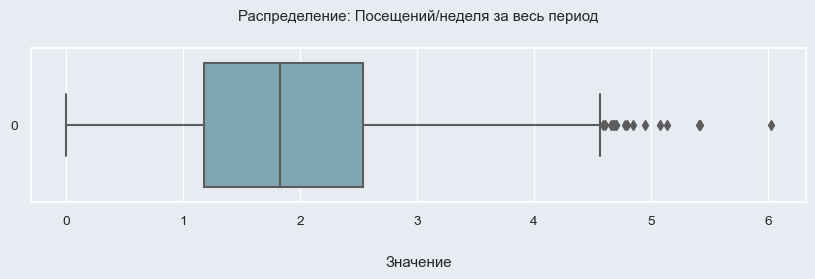

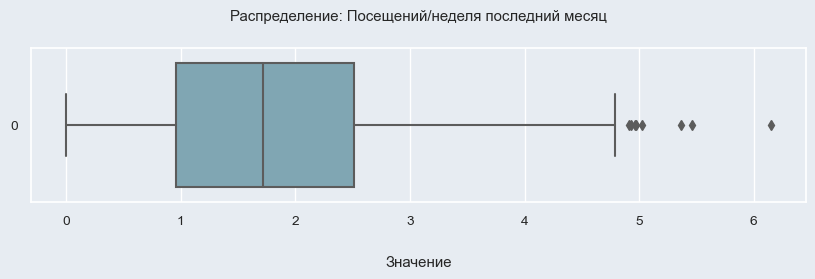

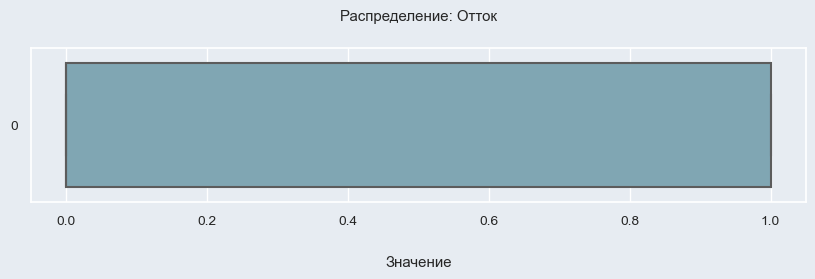

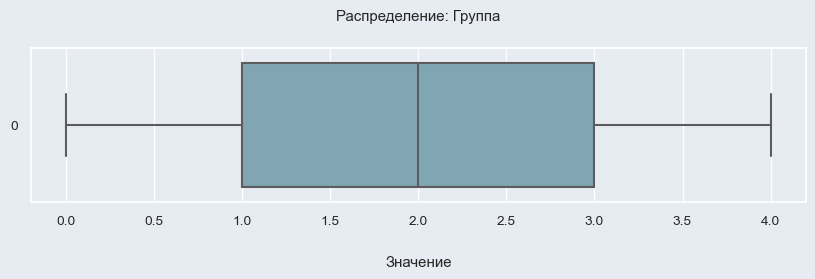

In [43]:
# Используем boxplot для небинарных переменных.
for i in data_ru_col.columns[7:13]:    
    sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'},font_scale= 0.9)
    plt.figure(figsize=(10,2))
    sns.boxplot(data_ru_col[i],palette='blend:#7AB,#EDA', orient='h')
    plt.title(f'Распределение: {i}', pad=20)
    plt.xlabel('Значение',labelpad=20)
    plt.show()

    Наши выбросы не ошибки измерений типичны в данном контексте. Они не сломают предположение прогностических моделей, так как являются незначительными.

In [1]:
# Посмотрим на средние значения переменных для ушедших и оставшихся.
churn_mean = data.groupby('churn').mean().T.reset_index()
churn_mean.columns = ['sign','stayed','leaved']
churn_mean['ratio'] = (churn_mean.stayed / churn_mean.leaved)
churn_mean.sort_values('ratio',ascending=False).style.format({'ratio':'{:.2%}', 'stayed':'{:.2f}', 'leaved':'{:.2f}'})

NameError: name 'data' is not defined

**Справочная информация по нашим данным:**    
    
1. **gender** - среднее одинаково, следовательно, признак не влияет на отток (с его помощью не удастся "растащить" данные по группам);
    
2. **Near_Location** (проживание или работа в районе, где находится фитнес-центр) - высокий показатель в обоих группах (больше "не оттока" среди тех, кто проживает и работает рядом с фитнесом). Соответственно, отток больше у тех, кто живет дальше. Можно сказать, что бинарный признак "близости к фитнесу" чуть слабее влияет на отток (чуть сильнее на то, чтобы клиент остался с нами);
    
3. **Partner** - это поле демонстрирует положительное влияние на клиентов (среди партнеров оттток меньше);
    
4. **Promo_friends** - это поле демонстрирует положительное влияние на клиентов (среди тех кто воспользовался промо оттток меньше);
    
5. **Phonе** - среднее одинаково, следовательно, признак не влияет на отток (с его помощью не удастся "растащить" данные по группам);
    
6. **Contract_period** (длительность текущего действующего абонемента (в месяцах): 1..6..12) - значительное положительное влияние на клиентов с простым объяснением (купили "длинный" абонемент, деньги терять жалко, будем заниматься);
    
7. **Group_visits** - это поле демонстрирует положительное влияние на клиентов (среди любителей посещать групповые занятия оттток меньше);
    
8. **Age** - среднее практически одинаково, следовательно, признак не влияет на отток (с его помощью не удастся "растащить" данные по группам);
    
9. **Avg_additional_charges_total** (суммарная выручка от других услуг фитнес-центра: кафе, спорттовары, косметический и массажный салон) - небольшое положительное влияние на клиентов (возможно если мы лояльны к фитнесу, то также лояльно относимся и к дополнительным услугам, которые в совокупности образуют экосистему здорового образа жизни);
    
10. **Month_to_end_contract** (срок до окончания текущего действующего абонемента (в месяцах): 1..6..12) - сильное положительное влияние на клиентов (чем больше срок действия моего абонемента - тем вероятнее, что я буду оставаться клиентом центра (возможно жалко "терять" абонемент);
    
11. **Lifetime** (время с момента первого обращения в фитнес-центр (в месяцах): 0..3..31) - очень сильное положительное влияние на клиентов (объяснение: со временем вырабатывается привычка);
    
12. **Avg_class_frequency_total** (средняя частота посещений в неделю за все время с начала действия абонемента) - положительное влияние на клиентов (чем чаще хожу заниматься, тем более мотивирован, очевидно);

13. **Avg_class_frequency_current_month** (средняя частота посещений в неделю за предыдущий месяц) - положительное влияние на клиентов с простым объяснением (чем чаще за неделю клиент ходил в фитнес в ближайщий период, тем привычка сильнее).
</div>


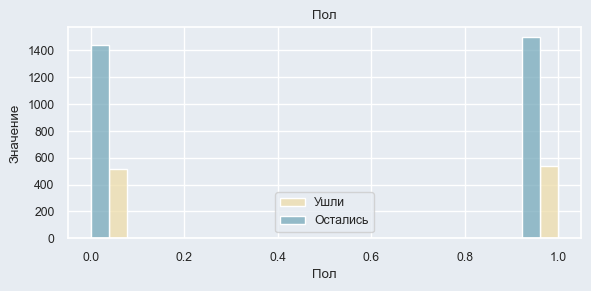

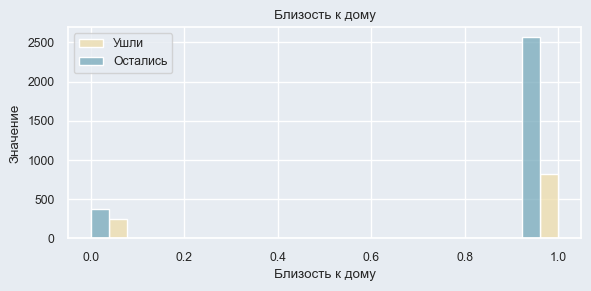

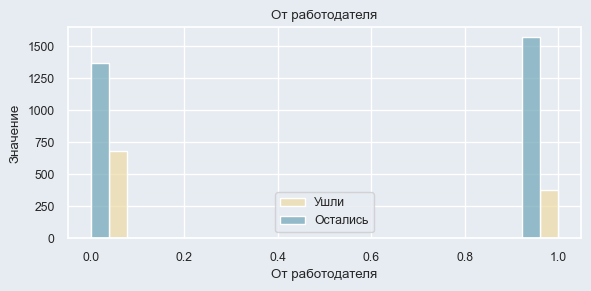

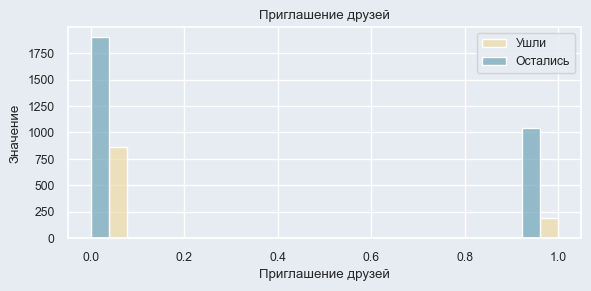

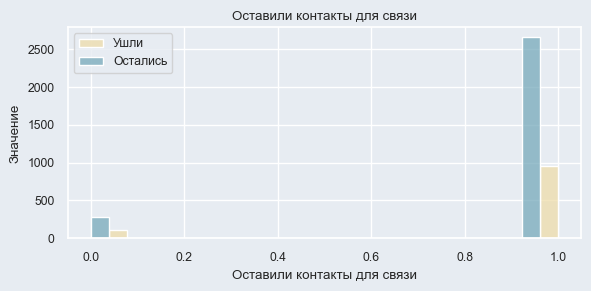

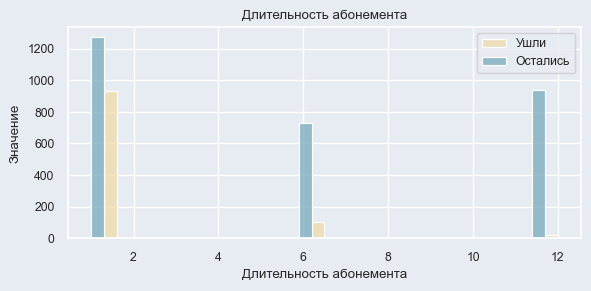

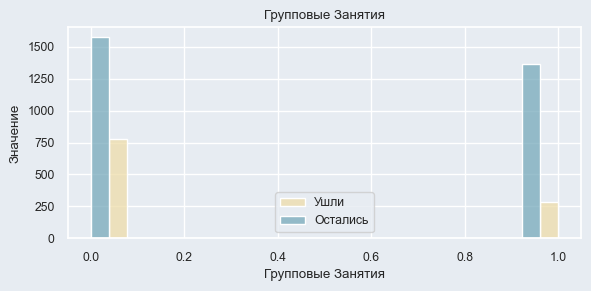

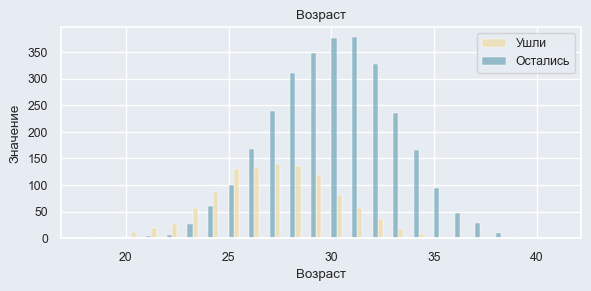

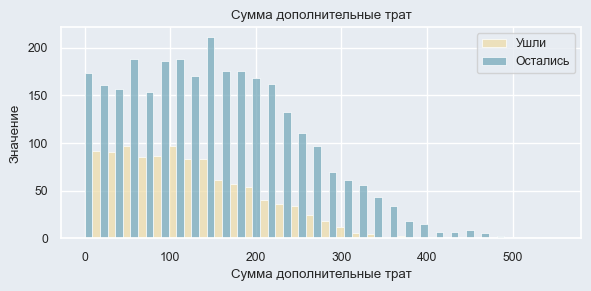

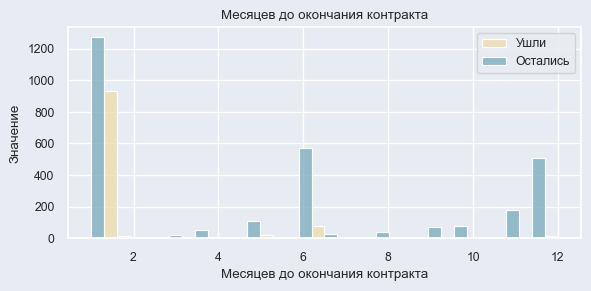

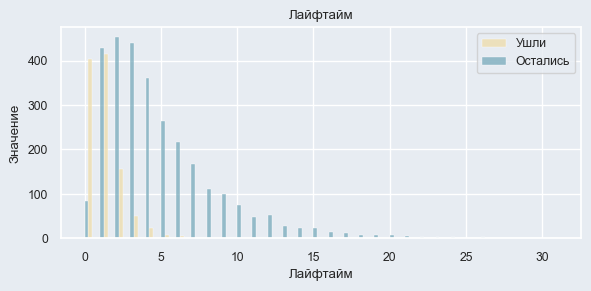

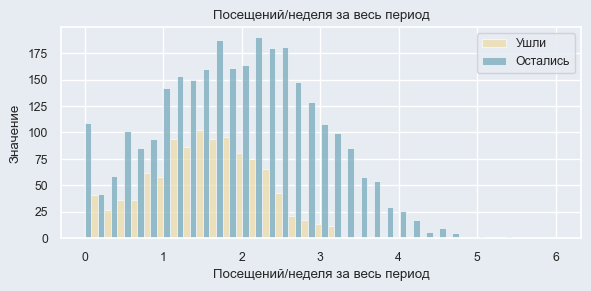

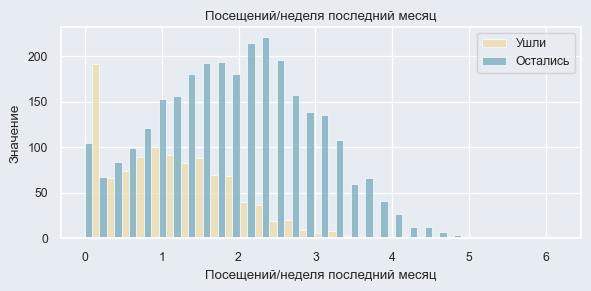

In [13]:
# Сравним распредление признаков для тех, кто ушёл и тех, кто остался  на столбчатых графиках.
for i in data_ru_col.columns[0:-1]:
    sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'}, font_scale=0.8)
    plt.figure(figsize=(6, 3))
    sns.histplot(data=data_ru_col, x=data_ru_col[i], hue='Отток', multiple="dodge", palette='blend:#7AB,#EDA')
    plt.legend(['Ушли', 'Остались'])
    plt.ylabel('Значение')
    plt.title(f'{i}')
    plt.tight_layout()

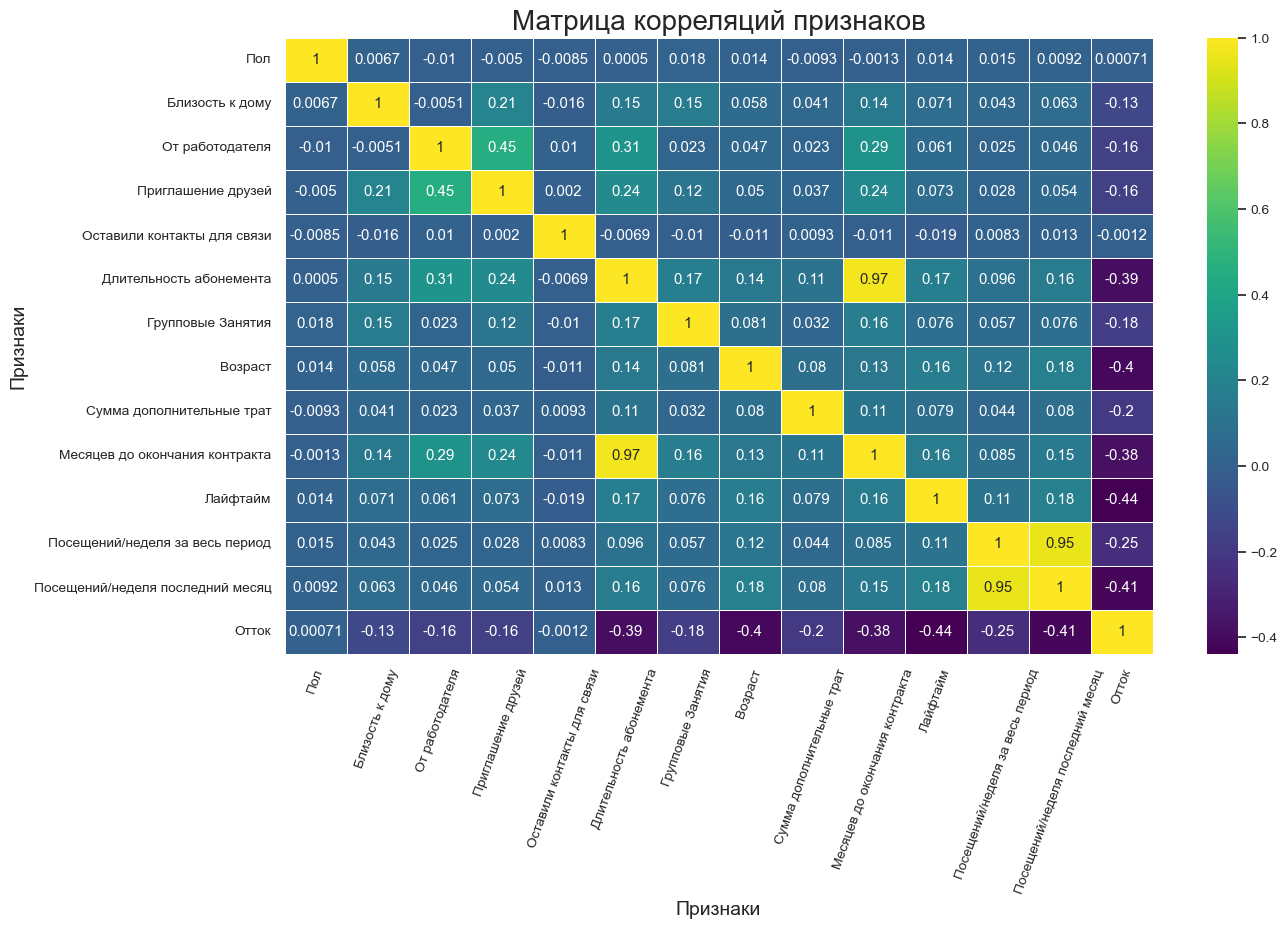

In [14]:
# Сделаем матрицу корреляции и посмотрим как связаны наши признаки.
sns.set(font_scale= 0.9)
matr = data_ru_col.corr()
plt.figure(figsize=(14,8))

sns.heatmap(matr, annot = True, square=False, cmap='viridis', linewidths =0.5)
plt.title('Матрица корреляций признаков', fontsize = 20)
plt.xlabel('Признаки', fontsize = 14) 
plt.ylabel('Признаки', fontsize = 14) 
plt.xticks(rotation=70)
plt.show()

    Очень высокую cкоррелированность этих 2х пар признаков (**Contract_period** - **Month_to_end_contract** и **Avg_class_frequency_current_month** - **Avg_class_frequency_total**) надо учитывать при построении некоторых моделей прогнозирования, чтобы избежать неустойчивости коэффициентов при построении наших моделей. 

<a id='1' a>

###  Выводы по блоку  "Исследовательский анализ данных."

**Общий вывод по состоянию датасета.**
  
   
   В файле содержится 4000 наблюдений и 14 колонок с признаками.Данные в хорошем состоянии.В них нет пропущенных значений дубликатов и выбросов обязательных для удаления. Все категориальные поля переведены в бинарное множество, а значит готовы для ML моделей.
  
**Влияние факторов на отток:**

**Значимые факторы**    

- Длительность текущего абонемента(большая часть ушедших приобрели абонемент на срок до трех месяцев).
- Срок до оконачения абонемента(Лишь в редких случаях клиенты бросают занятия при наличии длительного  оплаченного абонемента).
- Время с момента первого обращения(около 90 процентов от всех ушедших оформили договор не более трех месяцев назад).
- Частота посещения зала последний месяц(резкое прекращение регулярных тренировок обычно можети быть связано с форсмажорными обстоятельствами).
- Возраст(Как ни странно признак, который имеет высокую корреляцию с оттоком. Зрелые люди более отвественны к своему здоровью и прекрасно сознают значимость режима и регулярность спортивных нагрузок).Думаю значение этого фактора могло быть более значимым, если бы датасет не был ограничен клиентами, чей возраст не превышает 41 года.

**Малозначимые факторы:**
- Скидки по партнерской программе(возможность получить скидку от работодателя - безусловно мотиватор).
- Промокоды по приглашению друзей(тут имеет значение не только скидка, но и наличие компании знакомых или друзей).
- Частота посещения зала за всё время(фактор имеющий значение, но не так сильно, как интенсивность тренировок за последнее время)
- Групповые тренировки(клиенты посещающее групповые тренировки более вовлечены в спортивную культуру и реже бросают спорт в целом).
- Расстояние от зала(важный фактор, тем не менее не имеющий большого значения)
- Дополнительыне траты(финансовые вложение во многом определают значимость той или иной сферы жизни)

**Невлияющие факторы:** 
- Указанный в анекете контактного номера и пол посетителей не влияет на их отток.

Цифры говорят о том , что большую часть оттока составляют новички.Это клиенты оформившие договор недавно и на ненадолгий срок. Это может быть связано как с разочарованием инфраструктуры зала, так и отсутсвием естественной мотивации к занятию спортом.
В данных есть два сильно коррелирующих признака, которые верно будет удалить в случае работы с моделью линейной регресии.

## 3. Построение модели прогнозирования оттока клиентов.

<a id='2' a>

In [15]:
# Избавимся от коррелирующего признака в новой переменной для деревянной модели.
reg_tree_data = data.drop('contract_period',axis=1)

In [16]:
# Разбивает датасет на набор признаков и целевую переменную.
x_for_reg = reg_tree_data.drop('churn', axis = 1)
y_for_reg = reg_tree_data['churn']

x = data.drop('churn', axis = 1)
y = data['churn']

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x_for_reg, y_for_reg, test_size=0.2, random_state=0)

# обучим скейлер и преобразуем данные.
scaler = StandardScaler()
scaler.fit(x_train)
x_train_st = scaler.transform(x_train)
x_test_st = scaler.transform(x_test)

In [18]:
# Создаём функцию для применения метрик.
def met_func(name, model):
    print('-------------------------------------------------')
    model.fit(x_train_st, y_train)
    y_pred = model.predict(x_test_st)
    print("Модель", name)
    print("Accuracy =",accuracy_score(y_test, y_pred).round(3))
    print("Precision =", precision_score(y_test, y_pred).round(3))
    print("Recall =", recall_score(y_test, y_pred).round(3))
    print('-------------------------------------------------')

In [49]:
from math import factorial as f

In [19]:
model = LogisticRegression(random_state=0)
met_func('"Логическая регрессия"', model)
model = RandomForestClassifier(n_estimators = 100, random_state=0)
met_func('"Случайный лес"', model)

-------------------------------------------------
Модель "Логическая регрессия"
Accuracy = 0.925
Precision = 0.863
Recall = 0.828
-------------------------------------------------
-------------------------------------------------
Модель "Случайный лес"
Accuracy = 0.918
Precision = 0.844
Recall = 0.818
-------------------------------------------------


<a id='3' a> 
   
    

### Выводы по моделям прогнозирования:

Удалив колонку "contract_period" сильно коррелирующей с 'month_to_end_contract' во избежании мультиколлинеарности, можно сказать что:
- Обе метрики показали хорошие результаты.
- У метрики логической регресии результаты лучше. Для будущих прогнозов будем использовать её.

Удаление колонки из другой коррелирующей пары снизили эффективность обобщающего алгоритма модели и  привели к снижению показателей ключевых метрик.

<a id='4' a>

## 4. Кластеризация клиентов

In [20]:
# Стандартизируем данные
x_sc = scaler.fit_transform(x)
linked = linkage(x_sc, method = 'ward') 

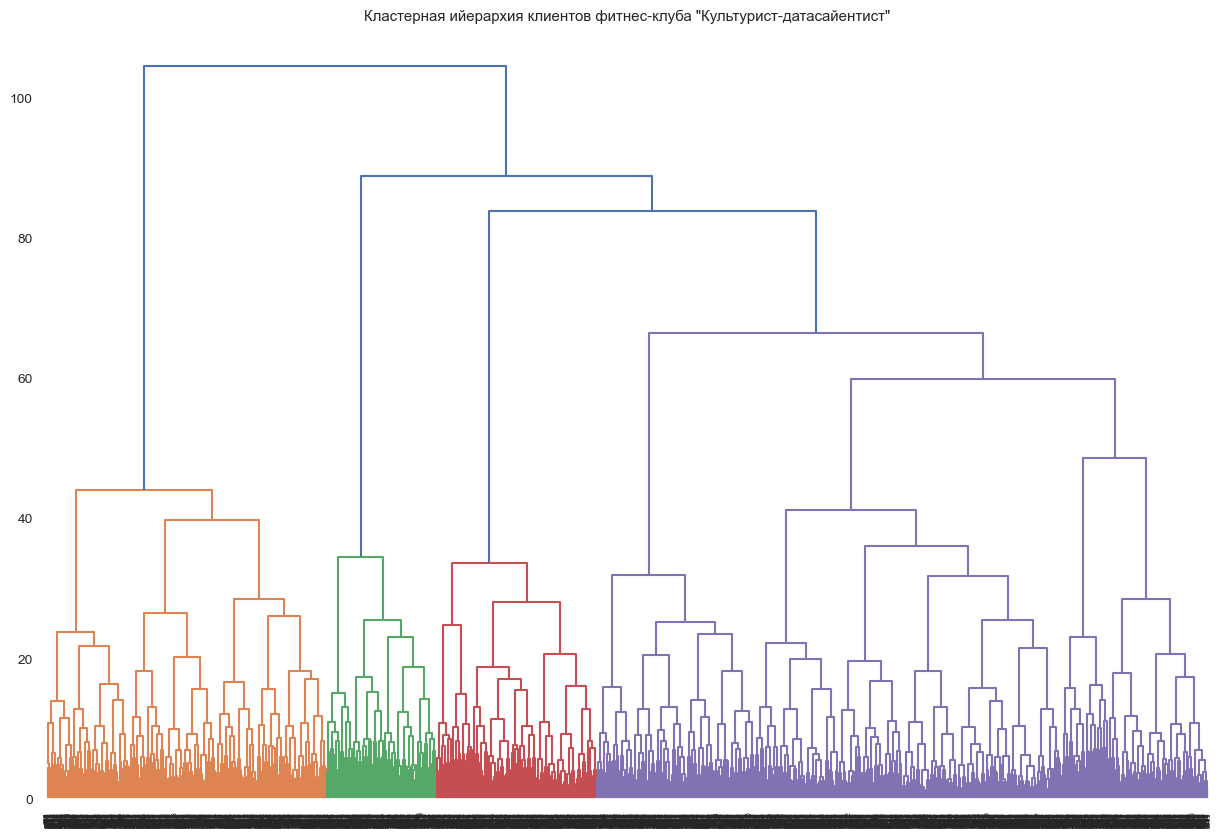

In [21]:
#Построим дендрограмму
plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('Кластерная ийерархия клиентов фитнес-клуба "Культурист-датасайентист"')
plt.show() 

    Теперь мы избавимся от колонок дублирущих друг друга и тех, что оказывают ничтожное влияние на отток.

In [22]:
data_ru_col = data_ru_col.drop(['Длительность абонемента','Пол','Оставили контакты для связи'],axis=1)

In [23]:
# стандартизируем, учим и получаем группы
x_sc = scaler.fit_transform(data_ru_col)
km = KMeans(n_clusters=5, random_state=0) 
labels = km.fit_predict(x_sc)

C:\Anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


     Мы отмасштабировали наши данные ("пропустили" через модель скейлера), построили дендрограмму, а затем обучили модель кластеризации (K-Means) на 5и кластерах. Далее посмотрим на сформированные группы.

In [24]:
data_ru_col['Группа'] = labels

In [25]:
data_ru_col.groupby('Группа').mean().T


Группа,0,1,2,3,4
Близость к дому,0.996368,1.000000,0.991257,0.000000,0.953725
От работодателя,0.347458,0.336228,0.914754,0.492063,0.308126
Приглашение друзей,0.049637,0.219603,0.979235,0.072310,0.089165
Групповые Занятия,0.427361,0.294045,0.558470,0.218695,0.478555
Возраст,30.156174,26.944169,29.829508,28.513228,30.079007
Сумма дополнительные трат,159.534524,114.470314,157.906560,133.805336,161.833176
Месяцев до окончания контракта,4.531477,1.705955,7.213115,2.649030,4.594808
Лайфтайм,4.756659,0.966501,4.664481,2.834215,4.871332
Посещений/неделя за весь период,1.169205,1.478928,1.955631,1.648643,2.973044
Посещений/неделя последний месяц,1.167377,1.046791,1.956096,1.463211,2.980554


<a id='3.5' a>

**Промежуточный итог:**

    Мы стандартизовали данные , "нарисовали" дендрограмму, визуально представив как наши клиенты "бьются" на кластеры , обучили модель кластеризации и посмотрели на средние значения признаков по всем 5 кластерам. 
    Уже на этом этапе руководство фитнес-центра получает понимание какими характеристиками обладают группы, которые уходят в "отток" и может выстраивать стратегию работы с "оттоком" так, чтобы максимально оставлять клиентов "в бизнесе". 
    Далее мы опишем группы , построим несколько графиков для всех групп и посмотрим на распределение. 


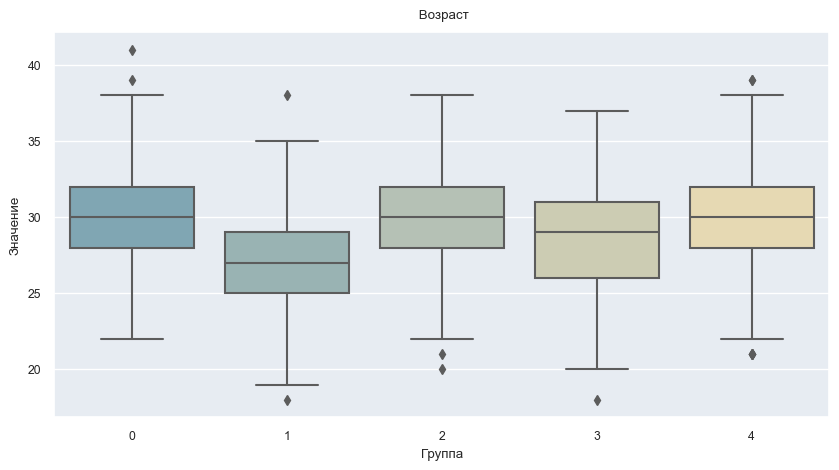

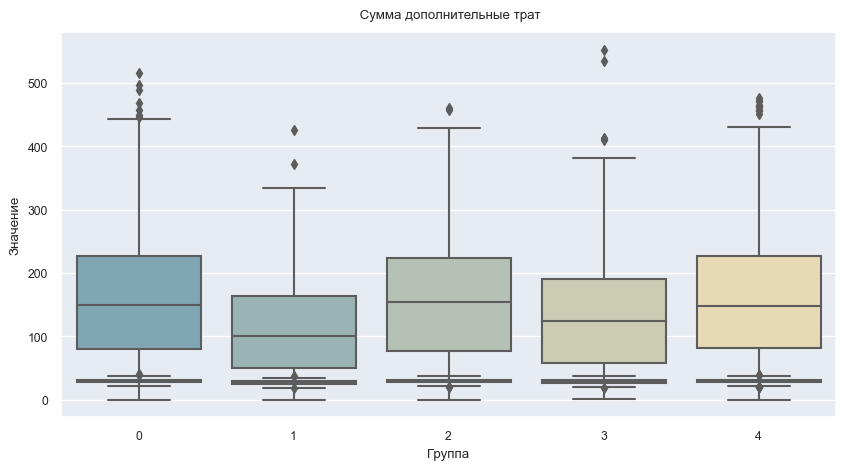

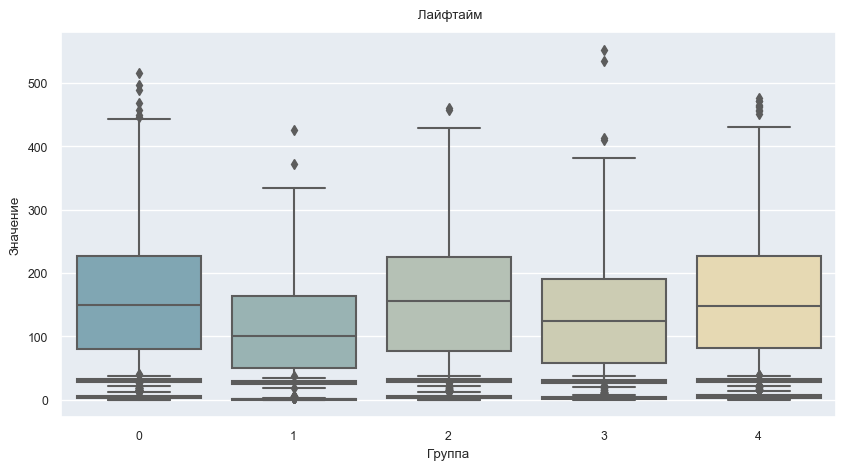

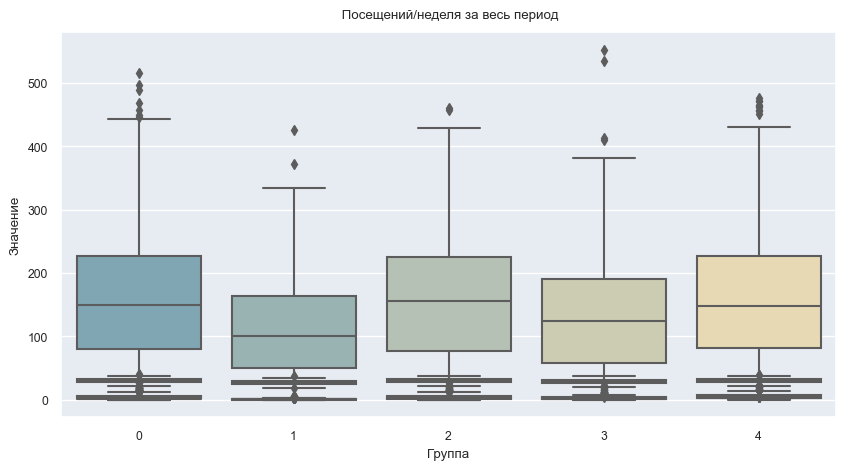

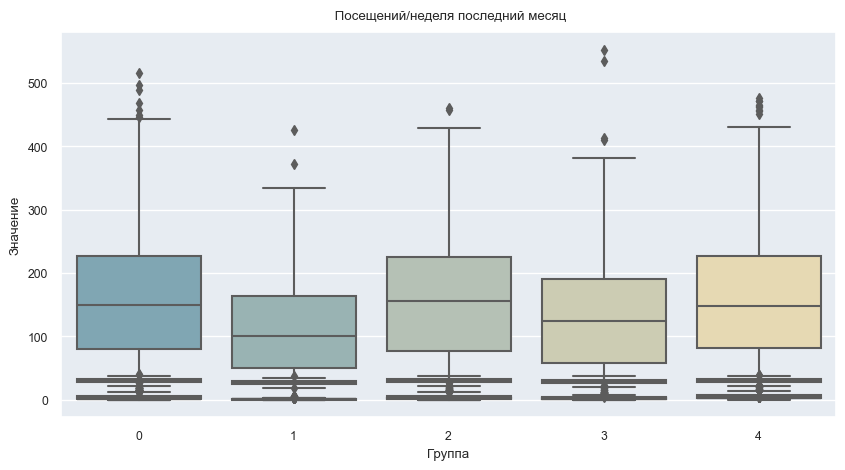

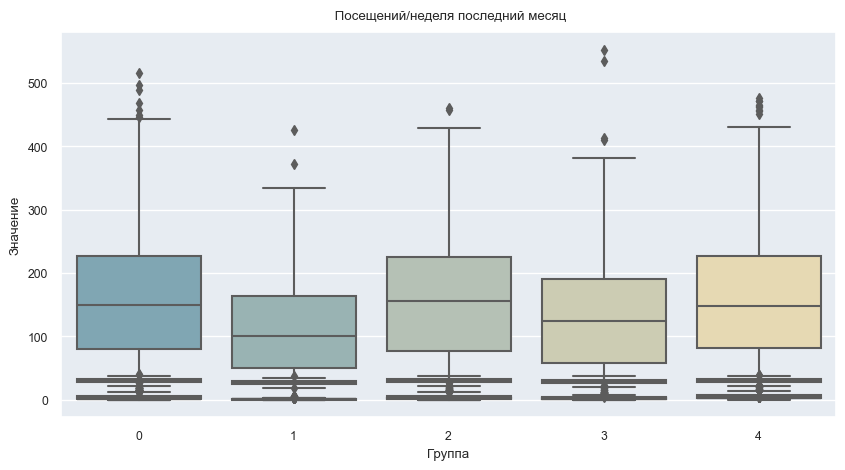

In [26]:
data_ru_col = data_ru_col.drop('Месяцев до окончания контракта',axis=1)
plt.figure(figsize=(10,5))
for i in data_ru_col.columns[4:-2]:
    sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'},font_scale= 0.8)
    sns.boxplot(data=data_ru_col ,x='Группа', y=data_ru_col[i], palette='blend:#7AB,#EDA')
    plt.title(f' {i}',pad=10)
    plt.ylabel('Значение')
    plt.show('');

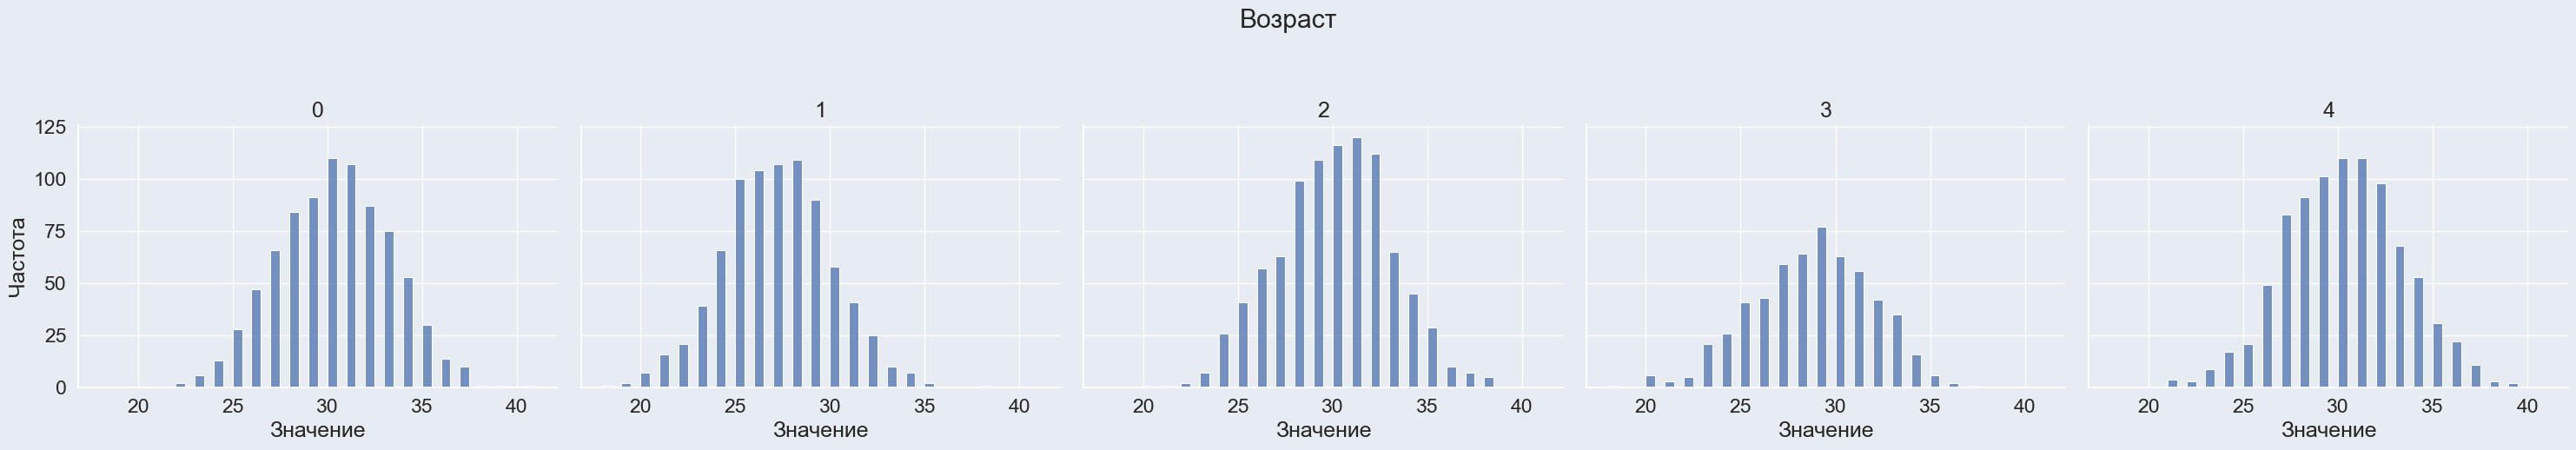

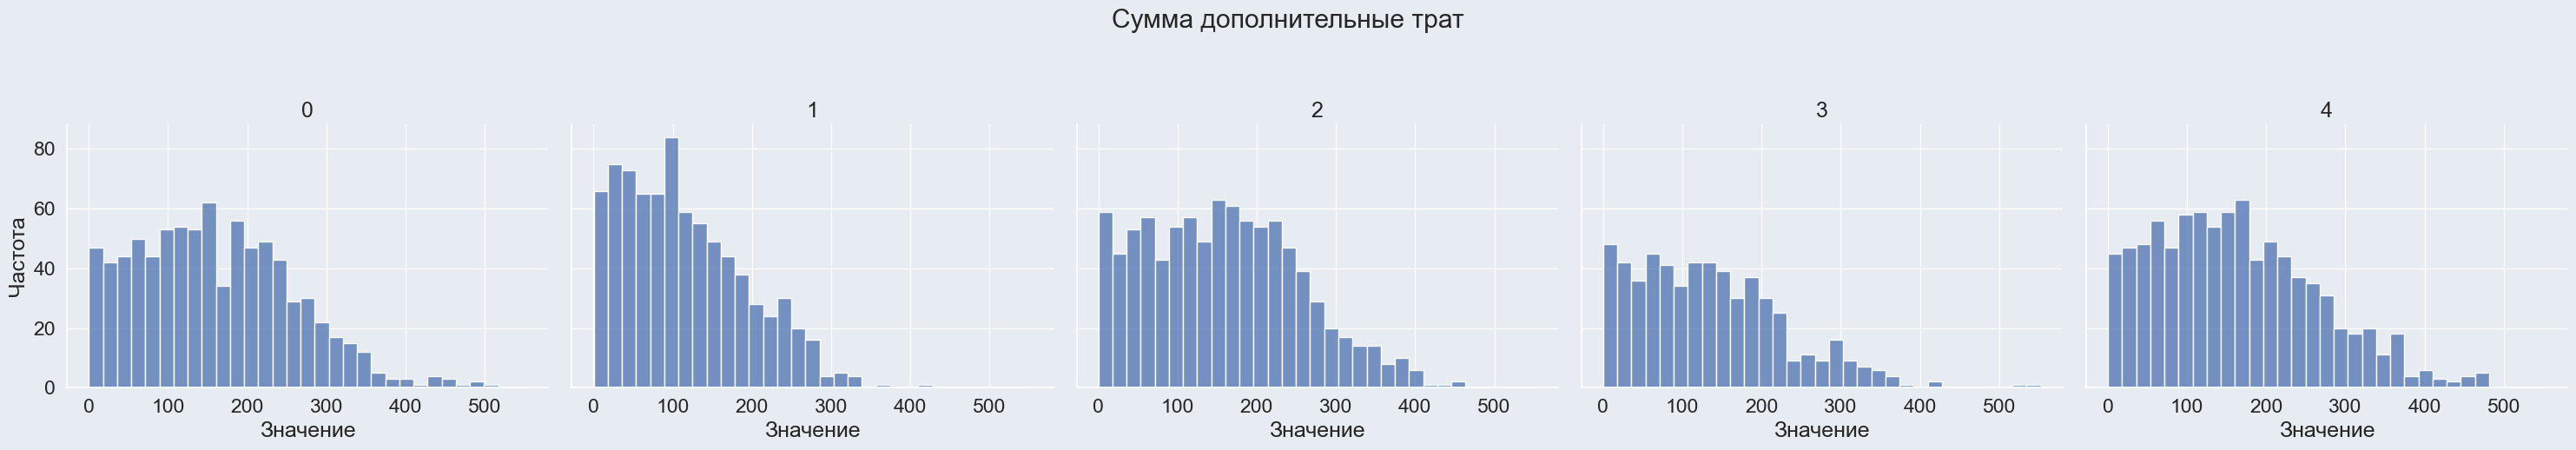

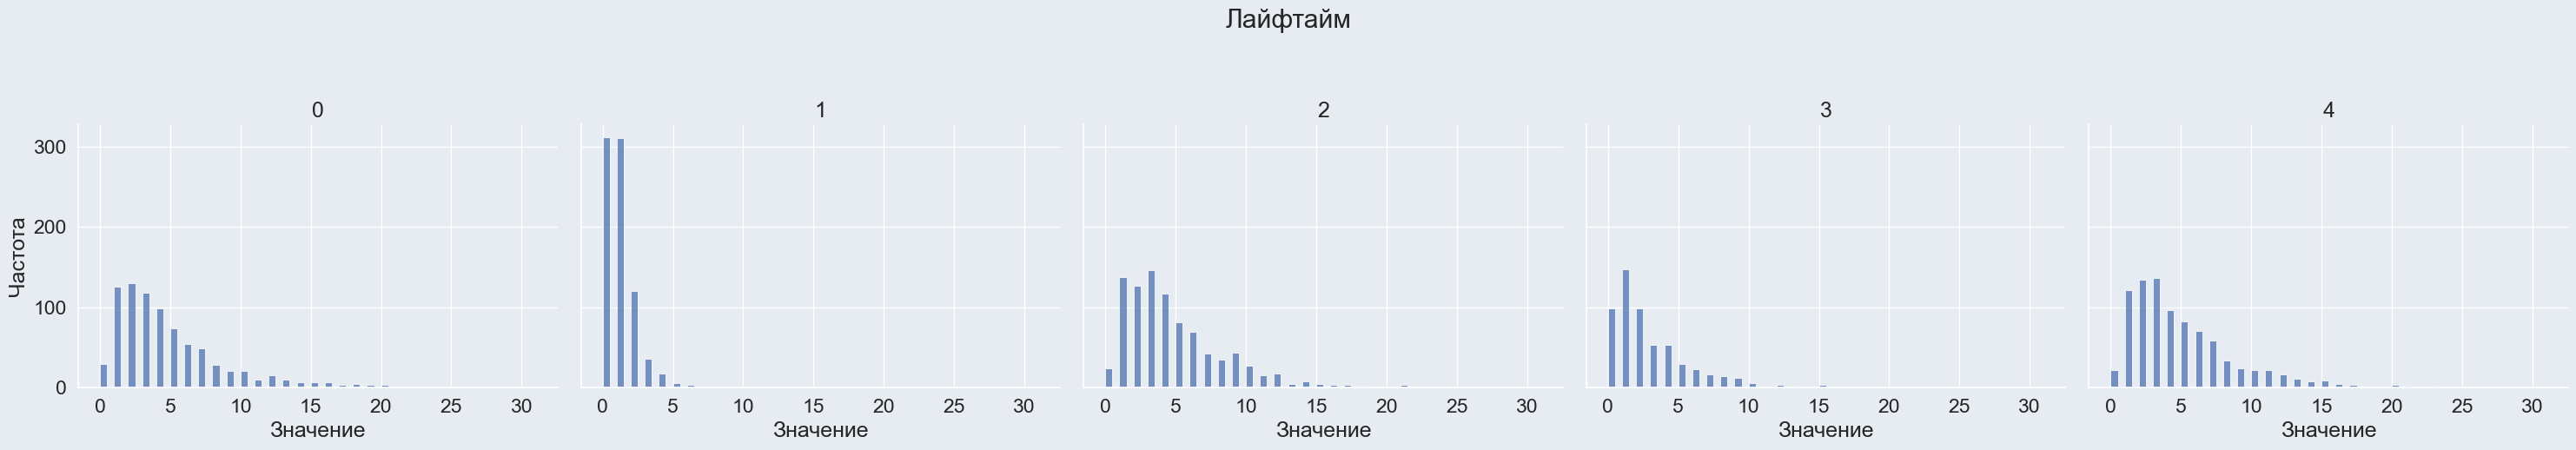

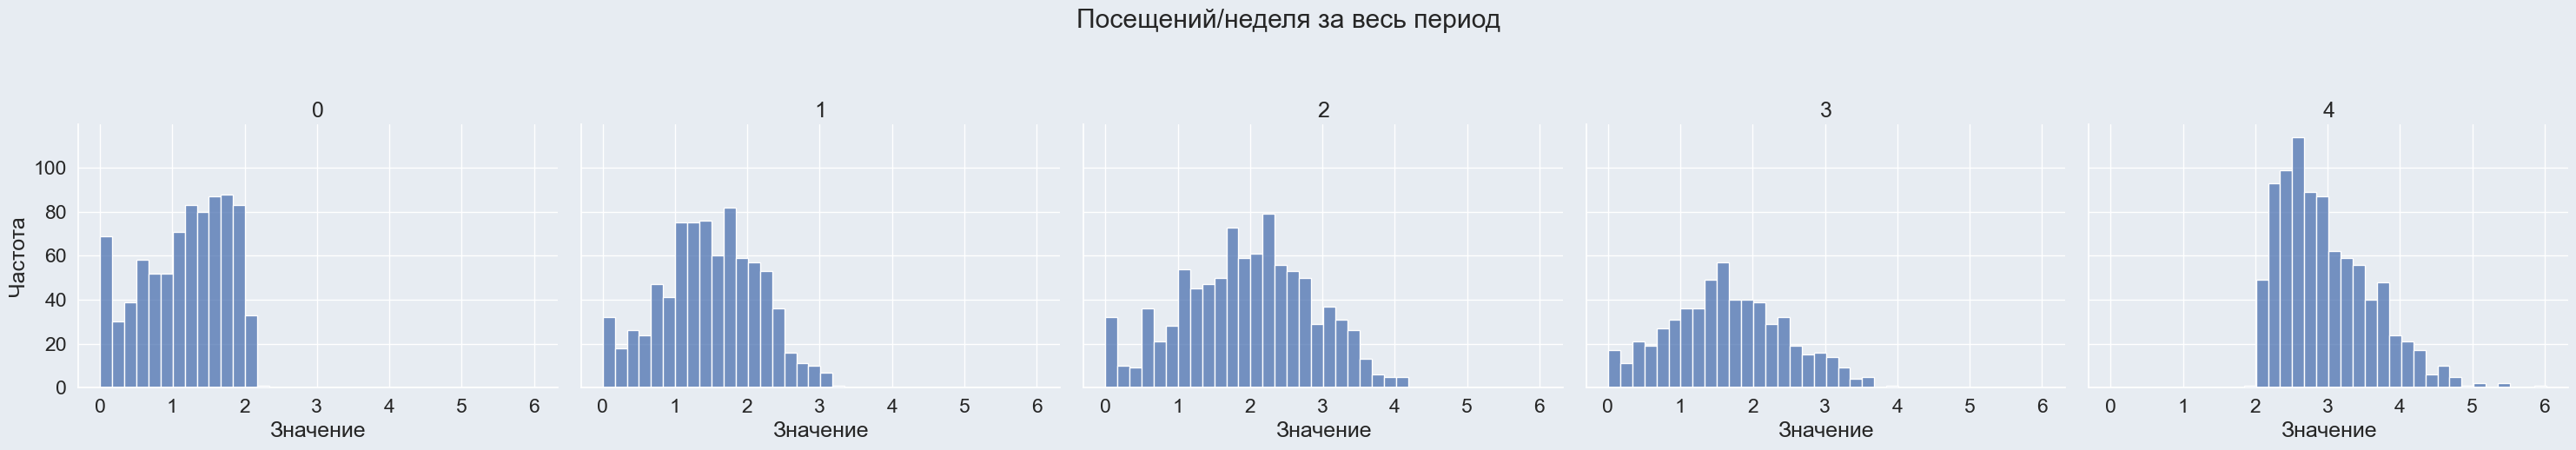

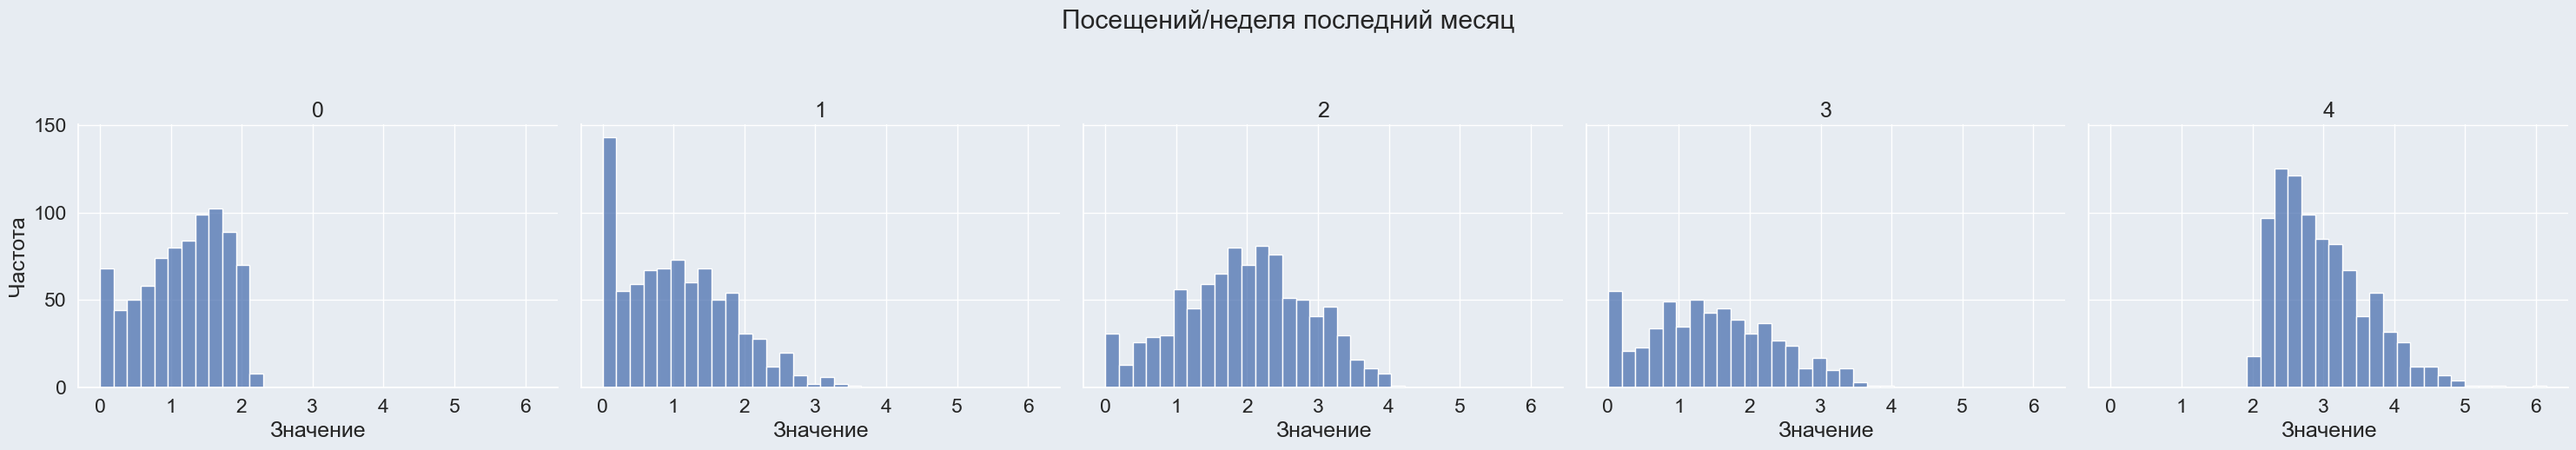

In [27]:
for i in data_ru_col.columns[4:-2]:
    sns.set(rc={'axes.facecolor':'#e7ecf2', 'figure.facecolor':'#e7ecf2'}, font_scale=1.5)    
    
    g = sns.displot(
        data=data_ru_col,
        x=data_ru_col[i],
        col='Группа',
        height=5,  
        aspect=1.2  
    )  
    
    g.fig.suptitle(f'{i}', y=1.05)    
    
    g.set_titles(col_template="{col_name}")      
    
    g.set_axis_labels(x_var='Значение', y_var='Частота')
    plt.tight_layout()
    
    plt.show()

<a id='5' a>

### Выводы по итогам кластеризации клиентов и выделение основных портретов .


Первая группа(0) **с оттоком 0%**. Последовательные и регулярны и несмотря на близкое расположение к дому/работе, чаще раза в неделю ходить зал они не готовы. Эта категория лояльна клубу и при достаточно редком посещении много тратят на дополнительные услуги. Вроятнее всего это одиночки, так как практически никто из них не использовал пригласительные промокоды.Кажется, их всё устраивает и бросать зал они не будут.
    
Вторая группа(1) **с оттоком 100%**. Те кто ушли. Причин тут может быть много. Разочарование в инвентаре зала, дополнительных услугах, так и отсуствие естественных стимулов. Большая часть из них новые клиенты, заключившие договор на короткий срок. Они моложе остальных, редко ходят, мало тратят и равнодушны в групповым тренировкам.
    
Третья группа(2) **с оттоком 0%**.  Отличительная черта  группы - это взоможность приобрести абонемент на долгий срок частично/полностью за счёт работодателя или по промокоду друзей.Чаще остальных посещают групповые тренировки и стабильно ходят два раза в неделю. Среди них почти нет тех, кто внезапно бросил занятия. Главный риск этой группы это высокая вероятность оттока в случае смены клиентами работы с отсутсвием партнёрской программы.
    
Четвёртая группа(3) с **оттоком 43%**.  Хотели бы ходить чаще чем полтора раза в неделю, но сильно ограничены расстоянием до зала, что медленно истоящает их мотивацию.Холодны к групповым занятиям и не использует промокоды друзей. Половина из этой группы отвалиывается по окончанию контракта, а те кто остаётся, скорее всего, делают это из за абонемента оплаченного работодателем.
    
Пятая группа(4) **с оттоком 0%**. Спорт плотно вплетён в их ритм жизни.Крайне мотивированные и наиболее лояльные пользователи, не зависящие от промокодов и парнерских программ. Больше остальных тратят на дополнительные услуги и регулярно занимаются три раза в неделю.Московскому городскому банку они наиболее симпатичны.

## 4. Общие выводы и рекомендации.

На основе представленных нам данных, которые были предобработаны и исследованы мы подобрали наилучшую модель для прогнозирования оттока клиентов. Модель была протестирована и показала очень высокие результаты по ключевым метрикам:

Accuracy = 0.925 (доля верно угаданных ответов из всех прогнозов)

Precision = 0.863 (доля правильных ответов при прогнозе ушедших клиентов)

Recall = 0.828 (долю верно классивфицированных объектов положительного класса)

На основе нашего исследования можно выделить основные факторы влияющие на отток:

- Длительность текущего абонемента(большая часть ушедших приобретали абонемент на ознакомительный срок до трех месяцев).
- Частота посещения зала последний месяц(тенденция к снижению количества тренировок).
- Небольшой лайфтайм(большинство прекративших тренировки являются новыми клиентами).
- Возраст (У возраста отрицательная корреляция с оттоком. Зрелые клиенты более лояльны клубу).

При помощи метода кластеризации мы сформировали 5 наиболее ярких групп с подробным описанием основных характеристик, свойств и отличий.На основе этих преобразований мы сформулируем основные рекомендации по повышению качества работы с клиентами.

Искать способы вовлечения новых клиентов в спортивную культуру:
- Бесплатные пробные занятия в группах и с тренером при оформление абонемента.
- Привлечение внимания к телеграму с публикациями статей о важности регулярного спорта и розыгрышами бесплатных разовых посещениях доп. услуг на выбор для новичков.
- Новых виды групповых тренировок ориентированных на молодежь.

Активно работать с клиентами в группах риска:      
- Предлагать разовые бесплатные акции клиентам чья интесивность посещений заметно снижается.Предлагать большие скидки для их друзей.
- Дополнительные скидки при оформлении абонемента тем, чей срок истекает.
- Искать возможность получить обратную связь от тех, кто тренировки так и не возобновил.





[На главную](#start)